# raiLPminer — validation & hypothesis analysis

**Hypothesis:** a graph-based depiction of a MILP allows identifying flaws *early* (before any solver is implemented).

Self-contained: with no API key it reproduces the analysis on the offline mock data. For a real sweep, replace the mock frame with the output of `run_agent_experiments(...)`. No diversity selection, no keyword matching — classification is embedded in generation and parsed deterministically.

In [1]:
import pandas as pd
from examples.mock_milps import MOCK_MILPS
from railpminer.analysis.graph_parser import create_graph_columns
from railpminer.analysis.screen import compute_graph_screen
from railpminer.validation.pipeline import validate_dataframe
from railpminer.analysis.hypothesis import (
    screen_confusion, evaluate_screen_against_solver, workflow_comparison)

/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Generate → deterministic classified parse → cheap graph screen → solve

For a real run replace the mock frame with `run_agent_experiments(...)` output and call `await validate_dataframe(df)` (generates solver code via an open model). Offline we use the precomputed `solver_code`.

In [2]:
df = pd.DataFrame(MOCK_MILPS)
df = create_graph_columns(df, column_name='answer')   # text or DC dict
df = compute_graph_screen(df)                          # solver-free verdict
df = await validate_dataframe(df, code_column='solver_code')
cols = ['workflow','case','parameter_count','graph_parse_ok','graph_complete',
        'graph_coherent','graph_linear','graph_safety_classes',
        'graph_predicts_valid','solver_optimal_all','solver_railway_safe_all',
        'solver_valid']
df[cols]

  0%|          | 0/7 [00:00<?, ?it/s]

 43%|████▎     | 3/7 [00:00<00:00, 27.50it/s]

100%|██████████| 7/7 [00:00<00:00, 45.36it/s]

,workflow,case,parameter_count,graph_parse_ok,graph_complete,graph_coherent,graph_linear,graph_safety_classes,graph_predicts_valid,solver_optimal_all,solver_railway_safe_all,solver_valid
0,SIM,good,7,True,True,True,True,True,True,True,True,True
1,TAF,good,7,True,True,True,True,True,True,True,True,True
2,DC,good,6,True,True,True,True,True,True,True,True,True
3,SIM,nonlinear,1,True,True,True,False,False,False,False,False,False
4,SIM,incomplete,1,True,False,False,True,False,False,False,False,False
5,SIM,empty,0,False,False,False,False,False,False,True,False,False
6,DC,missing_safety,2,True,True,True,True,False,False,True,False,False


## 2. Hypothesis: does the cheap screen predict the solver ground truth?

`early_catch_rate` = of all solver-flawed models, the fraction the graph flagged at zero solver cost. `false_alarm_rate` = valid models wrongly flagged.

In [3]:
pd.Series(screen_confusion(df))

n                   7.0
flawed              4.0
valid               3.0
tp_flawed_caught    4.0
fp_false_alarm      0.0
fn_flawed_missed    0.0
tn_valid_passed     3.0
early_catch_rate    1.0
false_alarm_rate    0.0
screen_precision    1.0
accuracy            1.0
dtype: float64

## 3. Which cheap signal does the work?

In [4]:
sig = evaluate_screen_against_solver(df)
sig[['flawed','early_catch_rate','false_alarm_rate','screen_precision','accuracy']]

,flawed,early_catch_rate,false_alarm_rate,screen_precision,accuracy
signal,,,,,
graph_predicts_valid,4,1.00,0.0,1.0,1.000000
graph_parse_ok,4,0.25,0.0,1.0,0.571429
graph_complete,4,0.50,0.0,1.0,0.714286
graph_coherent,4,0.50,0.0,1.0,0.714286
graph_linear,4,0.50,0.0,1.0,0.714286
graph_safety_classes,4,1.00,0.0,1.0,1.000000


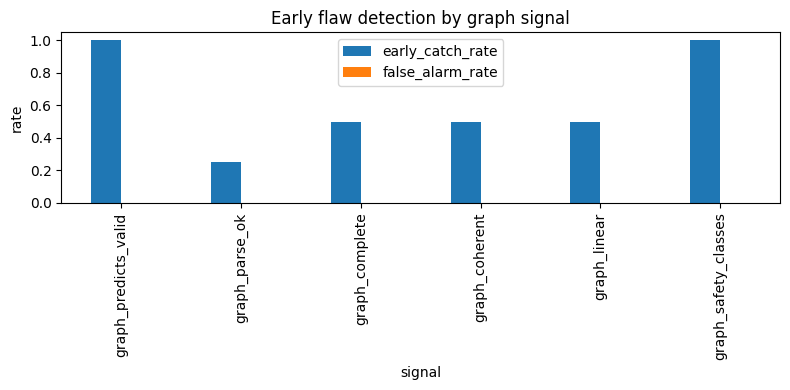

In [5]:
ax = sig[['early_catch_rate','false_alarm_rate']].plot.bar(
    figsize=(8,4), ylim=(0,1.05),
    title='Early flaw detection by graph signal')
ax.set_ylabel('rate'); ax.figure.tight_layout()

## 4. Graph-based workflows (SIM/TAF) vs the direct-code baseline (DC)

In [6]:
wc = workflow_comparison(df); wc

,n,solver_valid_rate,screen_pass_rate,early_catch_rate,false_alarm_rate,screen_accuracy
workflow,,,,,,
DC,2,0.50,0.50,1.0,0.0,1.0
SIM,4,0.25,0.25,1.0,0.0,1.0
TAF,1,1.00,1.00,NaN,0.0,1.0


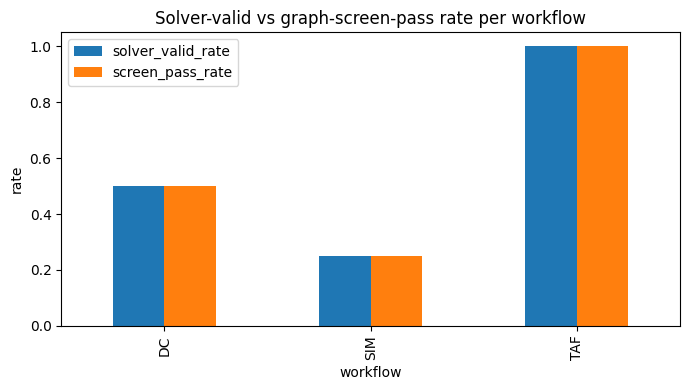

In [7]:
ax = wc[['solver_valid_rate','screen_pass_rate']].plot.bar(
    figsize=(7,4), ylim=(0,1.05),
    title='Solver-valid vs graph-screen-pass rate per workflow')
ax.set_ylabel('rate'); ax.figure.tight_layout()